In [24]:
import pandas
data=pandas.read_csv("datasets/pima_indians.csv")
data

,Number Children,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Age,Outcome
0,6,148,72,35,0,33.6,50,Likely to Have Diabetes
1,1,85,66,29,0,26.6,31,No Diabetes
2,8,183,64,0,0,23.3,32,Likely to Have Diabetes
3,1,89,66,23,94,28.1,21,No Diabetes
4,0,137,40,35,168,43.1,33,Likely to Have Diabetes
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,63,No Diabetes
764,2,122,70,27,0,36.8,27,No Diabetes
765,5,121,72,23,112,26.2,30,No Diabetes
766,1,126,60,0,0,30.1,47,Likely to Have Diabetes


In [25]:
data.describe()

,Number Children,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,33.240885
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,11.760232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,24.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,29.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,81.000000


/tmp/ipykernel_4523/3897600433.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Number Children",data=data,palette="Greens_d")


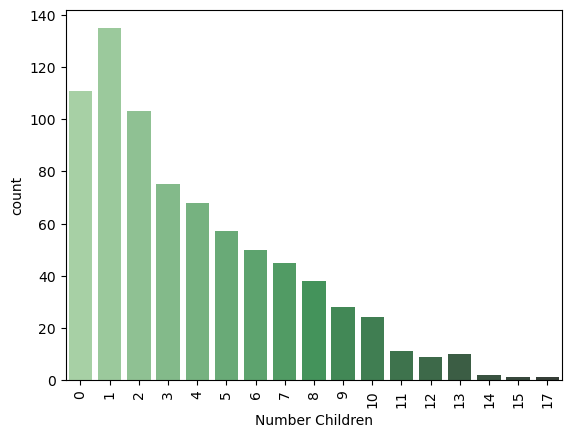

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Number Children",data=data,palette="Greens_d")
plt.xticks(rotation=90)
plt.savefig("Diabetes.png")

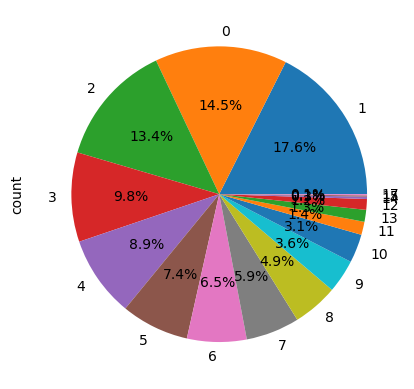

In [28]:
data['Number Children'].value_counts().plot.pie(autopct="%1.1f%%")
plt.savefig("piechart1.png")

In [30]:
array=data.values
X=array[:,0:7]
# X
Y=array[:,7]
# Y


In [ ]:
from sklearn import model_selection
X_train,X_test,Y_train,Y_test=model_selection.train_test_split(X,Y,test_size=0.30,random_state=42)

In [44]:
Y_train = Y_train.ravel()

In [45]:
from sklearn.svm import SVC 
model=SVC()
model.fit(X_train,Y_train)

SVC()

In [46]:
predictions=model.predict(X_test)
print("The predictions are",predictions)
print("The expected values are",Y_test)

The predictions are ['Likely to Have Diabetes' 'Likely to Have Diabetes'
 'Likely to Have Diabetes' 'No Diabetes' 'No Diabetes' 'No Diabetes'
 'Likely to Have Diabetes' 'Likely to Have Diabetes' 'No Diabetes'
 'No Diabetes' 'No Diabetes' 'No Diabetes' 'No Diabetes' 'No Diabetes'
 'No Diabetes' 'No Diabetes' 'No Diabetes' 'No Diabetes' 'No Diabetes'
 'No Diabetes' 'No Diabetes' 'No Diabetes' 'No Diabetes'
 'Likely to Have Diabetes' 'Likely to Have Diabetes' 'No Diabetes'
 'Likely to Have Diabetes' 'No Diabetes' 'No Diabetes'
 'Likely to Have Diabetes' 'No Diabetes' 'No Diabetes' 'No Diabetes'
 'Likely to Have Diabetes' 'No Diabetes' 'No Diabetes' 'No Diabetes'
 'No Diabetes' 'Likely to Have Diabetes' 'Likely to Have Diabetes'
 'Likely to Have Diabetes' 'Likely to Have Diabetes' 'No Diabetes'
 'No Diabetes' 'No Diabetes' 'No Diabetes' 'No Diabetes' 'No Diabetes'
 'No Diabetes' 'No Diabetes' 'No Diabetes' 'No Diabetes' 'No Diabetes'
 'Likely to Have Diabetes' 'Likely to Have Diabetes' 'No

In [47]:
from sklearn.metrics import accuracy_score
print("The accuracy is",accuracy_score(Y_test,predictions))

The accuracy is 0.7857142857142857


In [48]:

# Imports Classification Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC

# Create an Empty List and append all models, Give the Models an alias Name
# i.e we called KNeighborsClassifier() alias KNC etc
models = []
models.append(('D Trees', DecisionTreeClassifier()))
models.append(('Gaussian', GaussianNB()))
models.append(('KNC', KNeighborsClassifier()))
models.append(('Random Forest', RandomForestClassifier()))
models.append(('Gradient Boosting', GradientBoostingClassifier()))
models.append(('Linear Disc', LinearDiscriminantAnalysis()))
models.append(('Support Machines', SVC(gamma = 'auto')))

# Import Cross Validation and KFOLD
from sklearn.model_selection import cross_val_score, KFold
# Create a for loop so that each model is tested in turn
for name, model in models:
            # Here we do a 10 split K-FOLD
            kfold = KFold(n_splits = 10, random_state=42, shuffle=True)

            # We get the results for each Fold
            cv_results = cross_val_score(model, X_train, Y_train, cv = kfold,
            scoring='accuracy')

            # Get the average of all Folds
            print(name, ' Results:= ', cv_results.mean())


D Trees  Results:=  0.6953463775780011
Gaussian  Results:=  0.7540983606557377
KNC  Results:=  0.7231359069275516
Random Forest  Results:=  0.7491803278688526
Gradient Boosting  Results:=  0.7606292966684294
Linear Disc  Results:=  0.7705711263881545
Support Machines  Results:=  0.6595187731359069
